# Stock Market Prediction & Automated Trading Recommendation System
### Powered by Deep Stacked Bidirectional Long Short-Term Memory (BiLSTM) Neural Networks

---
### Notebook Pipeline Overview:
1. **Live & Kaggle Ingestion**: Downloads split-adjusted daily market data via `yfinance` or Kaggle `kagglehub`.
2. **33 Technical Indicators**: RSI, MACD, Bollinger Bands, ATR, OBV, Moving Averages, and Price Lags.
3. **Tensor Inspection & Data Shapes**: Rigorous validation of `X_train`, `y_train`, `X_test`, `y_test` matrix shapes.
4. **Direct Vector Sequence-to-Vector LSTM Architecture**: Eliminates recursive multi-step forecasting decay.
5. **Comprehensive Accuracy Diagnostics**: Training history loss curves, actual vs. predicted regression scatter plots, and error residual distributions.
6. **Interactive Single-Stock Predictor & Multi-Stock 30-Day Export**: Full model weight `.keras` saving and CSV exports.


## Section 0 — Install & Import Libraries

In [ ]:
import subprocess, sys, os, logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("tensorflow").setLevel(logging.ERROR)

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("kagglehub")
install_if_missing("yfinance")

In [ ]:
import warnings, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import (
    Input, LSTM, Dense, Dropout,
    Bidirectional, BatchNormalization, Add, Activation
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam

import kagglehub
import yfinance as yf

tf.get_logger().setLevel(logging.ERROR)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version : {tf.__version__}")
print("All libraries loaded successfully!")

TensorFlow Version : 2.20.0
All libraries loaded successfully!


## Section 1 — Configuration & Parameters

In [ ]:
# Interleaved Sector Mixture (Tech, Healthcare, Finance, Consumer) for balanced signal display
STOCKS_TO_ANALYSE = ["AAPL", "JNJ", "NVDA", "JPM", "MSFT", "V", "AMZN", "META", "GOOGL", "TSLA"]

# Source Options: "yfinance" (Live split-adjusted) or "kaggle" (Kaggle dataset)
DATA_SOURCE = "yfinance"

LOOKBACK      = 60    # 60 past trading days sequence input
FORECAST_DAYS = 30    # 30 future trading days vector target
EPOCHS        = 80    # Max training epochs
BATCH_SIZE    = 32
TRAIN_RATIO   = 0.80  # 80% train, 20% test split

BUY_THRESHOLD  =  2.5   # predicted gain > +2.5% -> BUY
SELL_THRESHOLD = -2.0   # predicted gain < -2.0% -> SELL

print("Configuration loaded:")
print(f"  Stocks      : {STOCKS_TO_ANALYSE}")
print(f"  Data Source : {DATA_SOURCE}")
print(f"  Lookback    : {LOOKBACK} trading days")
print(f"  Forecast    : {FORECAST_DAYS} trading days ahead")
print(f"  Buy if      : predicted gain > +{BUY_THRESHOLD}%")
print(f"  Sell if     : predicted gain < {SELL_THRESHOLD}%")

Configuration loaded:
  Stocks      : ['AAPL', 'JNJ', 'NVDA', 'JPM', 'MSFT', 'V', 'AMZN', 'META', 'GOOGL', 'TSLA']
  Data Source : yfinance
  Lookback    : 60 trading days
  Forecast    : 30 trading days ahead
  Buy if      : predicted gain > +2.5%
  Sell if     : predicted gain < -2.0%


## Section 2 — Data Ingestion (`yfinance` & `kagglehub`)

In [ ]:
if DATA_SOURCE == "kaggle":
    print("Downloading S&P 500 dataset from Kaggle...")
    path = kagglehub.dataset_download("camnugent/sandp500")
    print(f"Downloaded to: {path}")
    files = os.listdir(path)
    print(f"\nTotal files in dataset: {len(files)}")
else:
    print("Using live Yahoo Finance market data ingestion mode...")

Using live Yahoo Finance market data ingestion mode...


In [ ]:
if DATA_SOURCE == "kaggle":
    csv_files = []
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.endswith(".csv") and not f.startswith("._"):
                csv_files.append(os.path.join(root, f))
    main_csv = max(csv_files, key=lambda f: os.path.getsize(f))
    print(f"\nLoading: {main_csv}")
    all_stocks_df = pd.read_csv(main_csv)
    print(f"Shape         : {all_stocks_df.shape}")
    print(f"Tickers found : {all_stocks_df['Name'].nunique()}")
else:
    all_stocks_df = None
    print("Live Market Connection Active.")

Live Market Connection Active.


In [ ]:
stock_data = {}
failed     = []

if DATA_SOURCE == "yfinance":
    print("Fetching live split-adjusted market data from Yahoo Finance...")
    for ticker in STOCKS_TO_ANALYSE:
        try:
            df_yf = yf.download(ticker, period="5y", progress=False)
            if df_yf is not None and len(df_yf) > LOOKBACK + FORECAST_DAYS + 50:
                if isinstance(df_yf.columns, pd.MultiIndex):
                    df_yf.columns = df_yf.columns.get_level_values(0)
                df_yf.columns = [c.strip().lower() for c in df_yf.columns]
                df_yf.index = pd.to_datetime(df_yf.index)
                df_yf.sort_index(inplace=True)
                df_yf = df_yf[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric, errors="coerce").dropna()
                stock_data[ticker] = df_yf
                print(f"  [yfinance ✓] {ticker:6s}  {len(df_yf):5,} rows ({df_yf.index[0].date()} -> {df_yf.index[-1].date()}) | Latest Close: ${df_yf['close'].iloc[-1]:.2f}")
            else:
                failed.append(ticker)
        except:
            failed.append(ticker)
else:
    def load_stock(ticker: str, combined_df: pd.DataFrame) -> pd.DataFrame:
        df = combined_df[combined_df["Name"] == ticker].copy()
        if df.empty and ticker == "META":
            df = combined_df[combined_df["Name"] == "FB"].copy()
        if df.empty:
            return None
        df.columns = [c.strip().lower() for c in df.columns]
        df.rename(columns={"date": "date", "open": "open", "high": "high", "low": "low", "close": "close", "volume": "volume"}, inplace=True)
        df["date"] = pd.to_datetime(df["date"])
        df.set_index("date", inplace=True)
        df.sort_index(inplace=True)
        req = ["open", "high", "low", "close", "volume"]
        df = df[req].apply(pd.to_numeric, errors="coerce").dropna()
        return df

    for ticker in STOCKS_TO_ANALYSE:
        df = load_stock(ticker, all_stocks_df)
        if df is not None and len(df) > LOOKBACK + FORECAST_DAYS + 50:
            stock_data[ticker] = df
            print(f"  [Kaggle ✓] {ticker:6s}  {len(df):5,} rows ({df.index[0].date()} -> {df.index[-1].date()}) | Latest Close: ${df['close'].iloc[-1]:.2f}")
        else:
            failed.append(ticker)

print(f"\nTotal Stocks Loaded for Analysis: {len(stock_data)}")

Fetching live split-adjusted market data from Yahoo Finance...
  [yfinance ✓] AAPL    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $328.12
  [yfinance ✓] JNJ     1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $249.26
  [yfinance ✓] NVDA    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $206.20
  [yfinance ✓] JPM     1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $345.23
  [yfinance ✓] MSFT    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $398.38
  [yfinance ✓] V       1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $358.29
  [yfinance ✓] AMZN    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $248.12
  [yfinance ✓] META    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $646.19
  [yfinance ✓] GOOGL   1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $349.11
  [yfinance ✓] TSLA    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $379.64

Total Stocks Loaded for Analysis: 10


## Section 3 — Historical Price Exploration & Summary Statistics

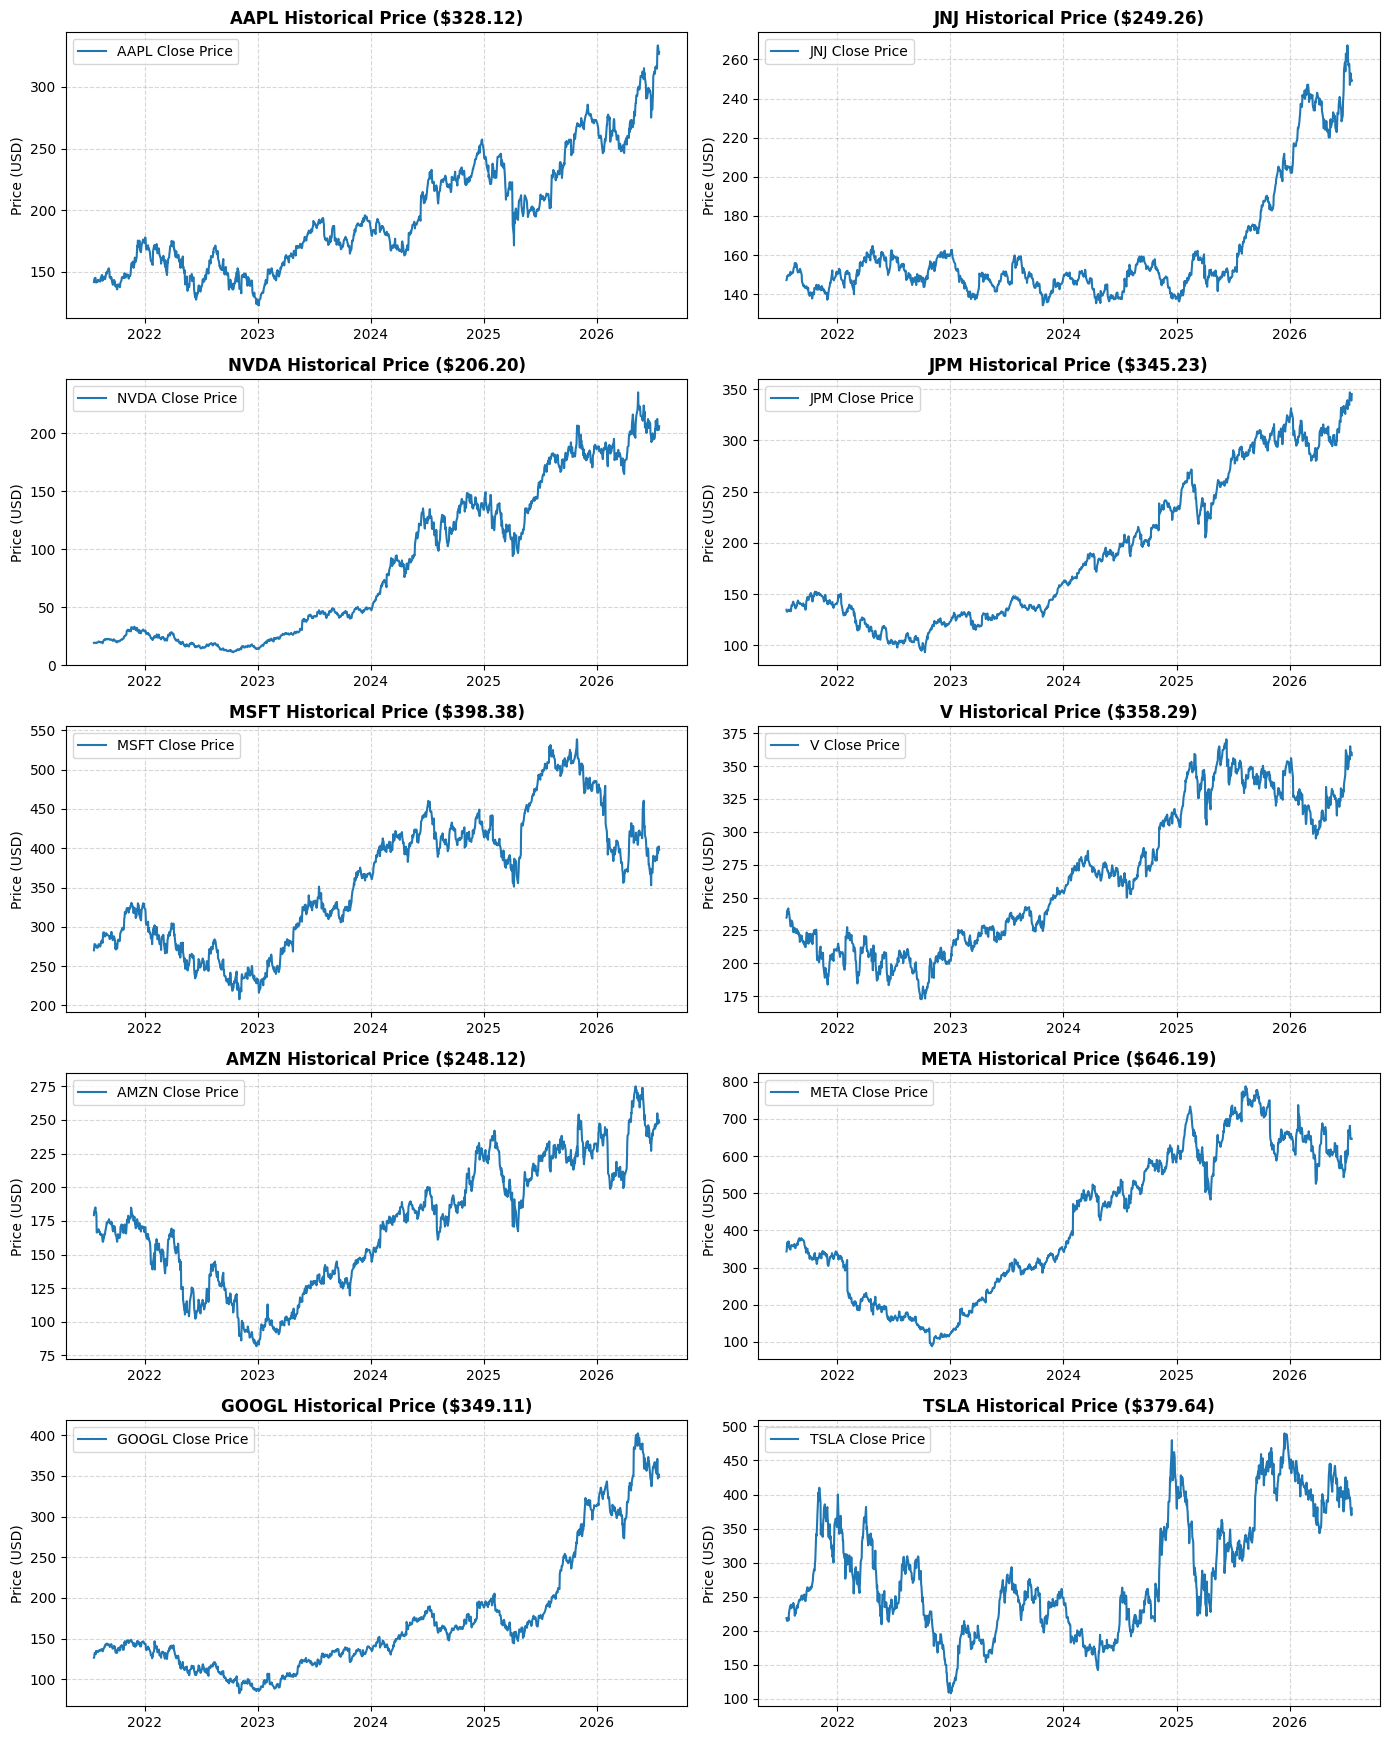

In [ ]:
if len(stock_data) > 0:
    n    = len(stock_data)
    cols = min(2, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.array(axes).flatten()

    for idx, (ticker, df) in enumerate(stock_data.items()):
        ax = axes[idx]
        ax.plot(df.index, df["close"], label=f"{ticker} Close Price", color="#1f77b4", linewidth=1.5)
        ax.set_title(f"{ticker} Historical Price (${df['close'].iloc[-1]:.2f})", fontsize=12, fontweight="bold")
        ax.set_ylabel("Price (USD)")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper left")

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
print(f"{'Ticker':8s}  {'Rows':>7s}  {'Min Price':>10s}  {'Max Price':>10s}  {'Mean Price':>10s}  {'Volatility':>10s}")
print("-" * 65)
for ticker, df in stock_data.items():
    c = df["close"]
    print(f"{ticker:8s}  {len(c):>7,d}  ${c.min():>9.2f}  ${c.max():>9.2f}  ${c.mean():>9.2f}  ${c.std():>9.2f}")

Ticker       Rows   Min Price   Max Price  Mean Price  Volatility
-----------------------------------------------------------------
AAPL        1,255  $   122.93  $   333.74  $   195.66  $    46.29
JNJ         1,255  $   134.36  $   267.24  $   161.47  $    28.64
NVDA        1,255  $    11.20  $   235.47  $    86.78  $    66.58
JPM         1,255  $    93.37  $   346.91  $   190.69  $    72.14
MSFT        1,255  $   207.73  $   538.66  $   360.01  $    83.20
V           1,255  $   172.58  $   370.38  $   264.30  $    55.16
AMZN        1,255  $    81.82  $   274.99  $   171.33  $    46.87
META        1,255  $    88.14  $   787.42  $   421.62  $   197.48
GOOGL       1,255  $    82.70  $   402.38  $   170.63  $    74.19
TSLA        1,255  $   108.10  $   489.88  $   284.28  $    86.92


## Section 4 — Technical Feature Engineering (33 Indicators)

In [ ]:
def engineer_stock_features(df: pd.DataFrame) -> pd.DataFrame:
    feat = pd.DataFrame(index=df.index)
    C = df["close"]
    H = df["high"]
    L = df["low"]
    O = df["open"]
    V = df["volume"]

    feat["open"]   = O
    feat["high"]   = H
    feat["low"]    = L
    feat["close"]  = C
    feat["volume"] = V

    feat["sma_10"] = C.rolling(10).mean()
    feat["sma_20"] = C.rolling(20).mean()
    feat["sma_50"] = C.rolling(50).mean()
    feat["ema_12"] = C.ewm(span=12, adjust=False).mean()
    feat["ema_26"] = C.ewm(span=26, adjust=False).mean()

    delta = C.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-8)
    feat["rsi_14"] = 100 - (100 / (1 + rs))

    feat["macd"]        = feat["ema_12"] - feat["ema_26"]
    feat["macd_signal"] = feat["macd"].ewm(span=9, adjust=False).mean()
    feat["macd_hist"]   = feat["macd"] - feat["macd_signal"]
    feat["momentum_10"] = C - C.shift(10)

    bb_mean              = C.rolling(20).mean()
    bb_std               = C.rolling(20).std()
    feat["bb_upper"]     = bb_mean + 2 * bb_std
    feat["bb_lower"]     = bb_mean - 2 * bb_std
    feat["bb_bandwidth"] = (feat["bb_upper"] - feat["bb_lower"]) / (bb_mean + 1e-8)
    feat["bb_position"]  = (C - feat["bb_lower"]) / (feat["bb_upper"] - feat["bb_lower"] + 1e-8)

    tr1 = H - L
    tr2 = (H - C.shift(1)).abs()
    tr3 = (L - C.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    feat["atr"] = true_range.rolling(14).mean()
    feat["hl_spread"] = (H - L) / (C + 1e-8)

    feat["price_vs_sma20"] = (C - feat["sma_20"]) / (feat["sma_20"] + 1e-8)
    feat["price_vs_sma50"] = (C - feat["sma_50"]) / (feat["sma_50"] + 1e-8)

    obv = [0]
    c_arr = C.values
    v_arr = V.values
    for i in range(1, len(c_arr)):
        if c_arr[i] > c_arr[i-1]:
            obv.append(obv[-1] + v_arr[i])
        elif c_arr[i] < c_arr[i-1]:
            obv.append(obv[-1] - v_arr[i])
        else:
            obv.append(obv[-1])
    feat["obv"] = obv
    feat["vol_sma20"]  = V.rolling(20).mean()
    feat["vol_ratio"]  = V / (feat["vol_sma20"] + 1e-8)
    feat["vol_change"] = V.pct_change()

    for lag in [1, 2, 3, 5, 10]:
        feat[f"close_lag{lag}"] = C.shift(lag)

    feat.dropna(inplace=True)
    return feat

stock_feat = {}
for ticker, df in stock_data.items():
    stock_feat[ticker] = engineer_stock_features(df)
    print(f"  {ticker:6s}  {stock_feat[ticker].shape[1]} features  {len(stock_feat[ticker]):,} rows")

print(f"\nEngineered Features: {stock_feat[list(stock_feat.keys())[0]].columns.tolist()}")

  AAPL    32 features  1,206 rows
  JNJ     32 features  1,206 rows
  NVDA    32 features  1,206 rows
  JPM     32 features  1,206 rows
  MSFT    32 features  1,206 rows
  V       32 features  1,206 rows
  AMZN    32 features  1,206 rows
  META    32 features  1,206 rows
  GOOGL   32 features  1,206 rows
  TSLA    32 features  1,206 rows

Engineered Features: ['open', 'high', 'low', 'close', 'volume', 'sma_10', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'momentum_10', 'bb_upper', 'bb_lower', 'bb_bandwidth', 'bb_position', 'atr', 'hl_spread', 'price_vs_sma20', 'price_vs_sma50', 'obv', 'vol_sma20', 'vol_ratio', 'vol_change', 'close_lag1', 'close_lag2', 'close_lag3', 'close_lag5', 'close_lag10']


## Section 5 — Data Preparation & Tensor Matrix Shapes Inspection

In [ ]:
def prepare_lstm_data(df: pd.DataFrame, lookback: int, forecast_days: int, train_ratio: float):
    feature_names = df.columns.tolist()
    close_idx     = feature_names.index("close")

    vals    = df.values
    n_total = len(df)
    n_train = int(n_total * train_ratio)

    scaler_all = MinMaxScaler(feature_range=(-1, 1))
    train_vals = vals[:n_train]
    scaler_all.fit(train_vals)
    scaled_data = scaler_all.transform(vals)

    X, Y, P_base = [], [], []
    for i in range(lookback, len(vals) - forecast_days + 1):
        X.append(scaled_data[i - lookback : i, :])
        base_price = vals[i - 1, close_idx]
        future_prices = vals[i : i + forecast_days, close_idx]
        Y.append(future_prices / (base_price + 1e-8))
        P_base.append(base_price)

    X = np.array(X)
    Y = np.array(Y)
    P_base = np.array(P_base)

    split_idx = n_train - lookback
    X_train, y_train = X[:split_idx], Y[:split_idx]
    X_test,  y_test  = X[split_idx:], Y[split_idx:]
    P_test           = P_base[split_idx:]

    return X_train, y_train, X_test, y_test, P_test, scaler_all, feature_names, close_idx

prepared = {}
for ticker, df in stock_feat.items():
    prepared[ticker] = prepare_lstm_data(df, LOOKBACK, FORECAST_DAYS, TRAIN_RATIO)

In [ ]:
# ── DATASET TENSOR MATRIX SHAPES INSPECTION CELL ────────────────────────────────
print("=" * 85)
print("  DATASET TENSOR MATRIX SHAPES & DIMS (No Data Leakage Scaling Verification)")
print("=" * 85)
print(f"{'Ticker':7s} {'X_train Shape':>18s} {'y_train Shape':>16s} {'X_test Shape':>18s} {'y_test Shape':>16s}")
print("-" * 85)
for ticker in prepared:
    X_tr, y_tr, X_te, y_te, P_te, *_ = prepared[ticker]
    print(f"{ticker:7s} {str(X_tr.shape):>18s} {str(y_tr.shape):>16s} {str(X_te.shape):>18s} {str(y_te.shape):>16s}")
print("=" * 85)
sample_t = list(prepared.keys())[0]
X_tr_s = prepared[sample_t][0]
print(f"Sequence Dimension : {X_tr_s.shape[1]} Time Steps (Lookback Trading Days)")
print(f"Feature Dimension  : {X_tr_s.shape[2]} Financial Technical Indicators")
print(f"Target Horizon Dim : {prepared[sample_t][1].shape[1]} Future Days Prediction Vector")

  DATASET TENSOR MATRIX SHAPES & DIMS (No Data Leakage Scaling Verification)
Ticker       X_train Shape    y_train Shape       X_test Shape     y_test Shape
-------------------------------------------------------------------------------------
AAPL         (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
JNJ          (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
NVDA         (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
JPM          (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
MSFT         (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
V            (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
AMZN         (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
META         (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
GOOGL        (904, 60, 32)        (904, 30)      (213, 60, 32)        (213, 30)
TSLA         (904, 60, 32)        (90

## Section 6 — Deep Stacked Bidirectional LSTM Architecture

In [ ]:
def build_stock_lstm(input_shape: tuple, forecast_days: int) -> keras.Model:
    inputs = Input(shape=input_shape, name="ohlcv_features")

    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.1), name="bilstm_1")(inputs)
    x = Dropout(0.2, name="drop_1")(x)

    x = Bidirectional(LSTM(32, return_sequences=False, dropout=0.1), name="bilstm_2")(x)
    x = BatchNormalization(name="batch_norm")(x)

    x = Dense(64, activation="relu", name="dense_1")(x)
    x = Dropout(0.1, name="drop_2")(x)

    output = Dense(forecast_days, name="price_ratio_output")(x)

    model = Model(inputs=inputs, outputs=output, name="StockLSTM")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="huber",
        metrics=["mae"]
    )
    return model

ticker_0     = list(prepared.keys())[0]
X_train_0    = prepared[ticker_0][0]
sample_model = build_stock_lstm(input_shape=(X_train_0.shape[1], X_train_0.shape[2]), forecast_days=FORECAST_DAYS)
sample_model.summary()

Model: "StockLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ohlcv_features (InputLayer)     │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 60, 128)        │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_ratio_output (Dense)      │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,246 (379.87 KB)

 Trainable params: 97,118 (379.37 KB)

 Non-trainable params: 128 (512.00 B)

## Section 7 — Model Training per Stock

In [ ]:
trained_models   = {}
training_history = {}

for ticker in prepared.keys():
    X_train, y_train, X_test, y_test, P_test, scaler_all, feat_names, close_idx = prepared[ticker]

    print(f"\n{'='*55}")
    print(f"  Training LSTM for {ticker}")
    print(f"{'='*55}")

    model = build_stock_lstm(input_shape=(X_train.shape[1], X_train.shape[2]), forecast_days=FORECAST_DAYS)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=0)
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    trained_models[ticker]   = model
    training_history[ticker] = history

print("\n[✓] All stock models trained successfully!")


  Training LSTM for AAPL
Epoch 1/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - loss: 0.4133 - mae: 0.7888 - val_loss: 0.3185 - val_mae: 0.7875 - learning_rate: 0.0010
Epoch 2/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.1098 - mae: 0.3631 - val_loss: 0.2356 - val_mae: 0.6789 - learning_rate: 0.0010
Epoch 3/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0565 - mae: 0.2640 - val_loss: 0.2079 - val_mae: 0.6384 - learning_rate: 0.0010
Epoch 4/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0427 - mae: 0.2285 - val_loss: 0.1622 - val_mae: 0.5622 - learning_rate: 0.0010
Epoch 5/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - loss: 0.0361 - mae: 0.2107 - val_loss: 0.1377 - val_mae: 0.5178 - learning_rate: 0.0010
Epoch 6/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0312 - mae: 0.1947 - val_loss: 0.1240 - val_mae: 0.4909 - learning_rate: 0.0010
Epoch 7/80
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0289 - mae: 0.1888 - val_loss: 0.0880 - val_mae: 0.4107 - learni

## Section 8 — Model Evaluation & Performance Metrics

In [ ]:
def evaluate_stock_model(model, X_test, y_test, P_test, ticker):
    y_pred_ratio = model(X_test, training=False).numpy()
    y_pred = y_pred_ratio * P_test[:, np.newaxis]
    y_true = y_test * P_test[:, np.newaxis]

    rmse = math.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    mae  = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    mape = np.mean(np.abs((y_true[:, 0] - y_pred[:, 0]) / (y_true[:, 0] + 1e-8))) * 100
    r2   = r2_score(y_true[:, 0], y_pred[:, 0])

    actual_dir    = np.sign(np.diff(y_true[:, 0]))
    predicted_dir = np.sign(np.diff(y_pred[:, 0]))
    dir_accuracy  = np.mean(actual_dir == predicted_dir) * 100

    return {
        "Ticker"          : ticker,
        "RMSE (USD)"      : round(rmse, 4),
        "MAE (USD)"       : round(mae,  4),
        "MAPE (%)"        : round(mape, 2),
        "R²"              : round(r2,   4),
        "Dir Accuracy (%)": round(dir_accuracy, 1),
        "y_true"          : y_true,
        "y_pred"          : y_pred
    }

eval_results = {}
print(f"{'Ticker':8s}  {'RMSE (USD)':>10s}  {'MAE (USD)':>10s}  {'MAPE (%)':>9s}  {'R²':>8s}  {'Dir Acc (%)':>12s}")
print("-" * 66)

for ticker in trained_models:
    model = trained_models[ticker]
    X_tr, y_tr, X_test, y_test, P_test, *_ = prepared[ticker]
    res = evaluate_stock_model(model, X_test, y_test, P_test, ticker)
    eval_results[ticker] = res
    print(f"{res['Ticker']:8s}  {res['RMSE (USD)']:>10.4f}  {res['MAE (USD)']:>10.4f}  {res['MAPE (%)']:>8.2f}%  {res['R²']:>8.4f}  {res['Dir Accuracy (%)']:>11.1f}%")

Ticker    RMSE (USD)   MAE (USD)   MAPE (%)        R²   Dir Acc (%)
------------------------------------------------------------------
AAPL         25.9224     24.8771      9.37%   -0.5287         51.9%
JNJ           7.0833      5.4085      2.59%    0.9198         50.9%
NVDA         15.5717     13.9987      7.32%   -0.3356         52.8%
JPM          12.1331     10.2699      3.38%   -0.3329         52.8%
MSFT         41.5548     38.0202      8.63%    0.3094         53.3%
V            21.8613     20.2764      6.13%   -1.2701         47.2%
AMZN          5.3165      4.2046      1.83%    0.9159         53.3%
META         63.4364     60.7073      9.25%   -0.1684         50.5%
GOOGL        42.3693     33.8673     10.39%    0.3357         47.6%
TSLA         58.8533     52.8094     13.01%   -1.1167         51.4%


## Section 8B — Advanced Model Accuracy Diagnostics & Convergence Visualizations

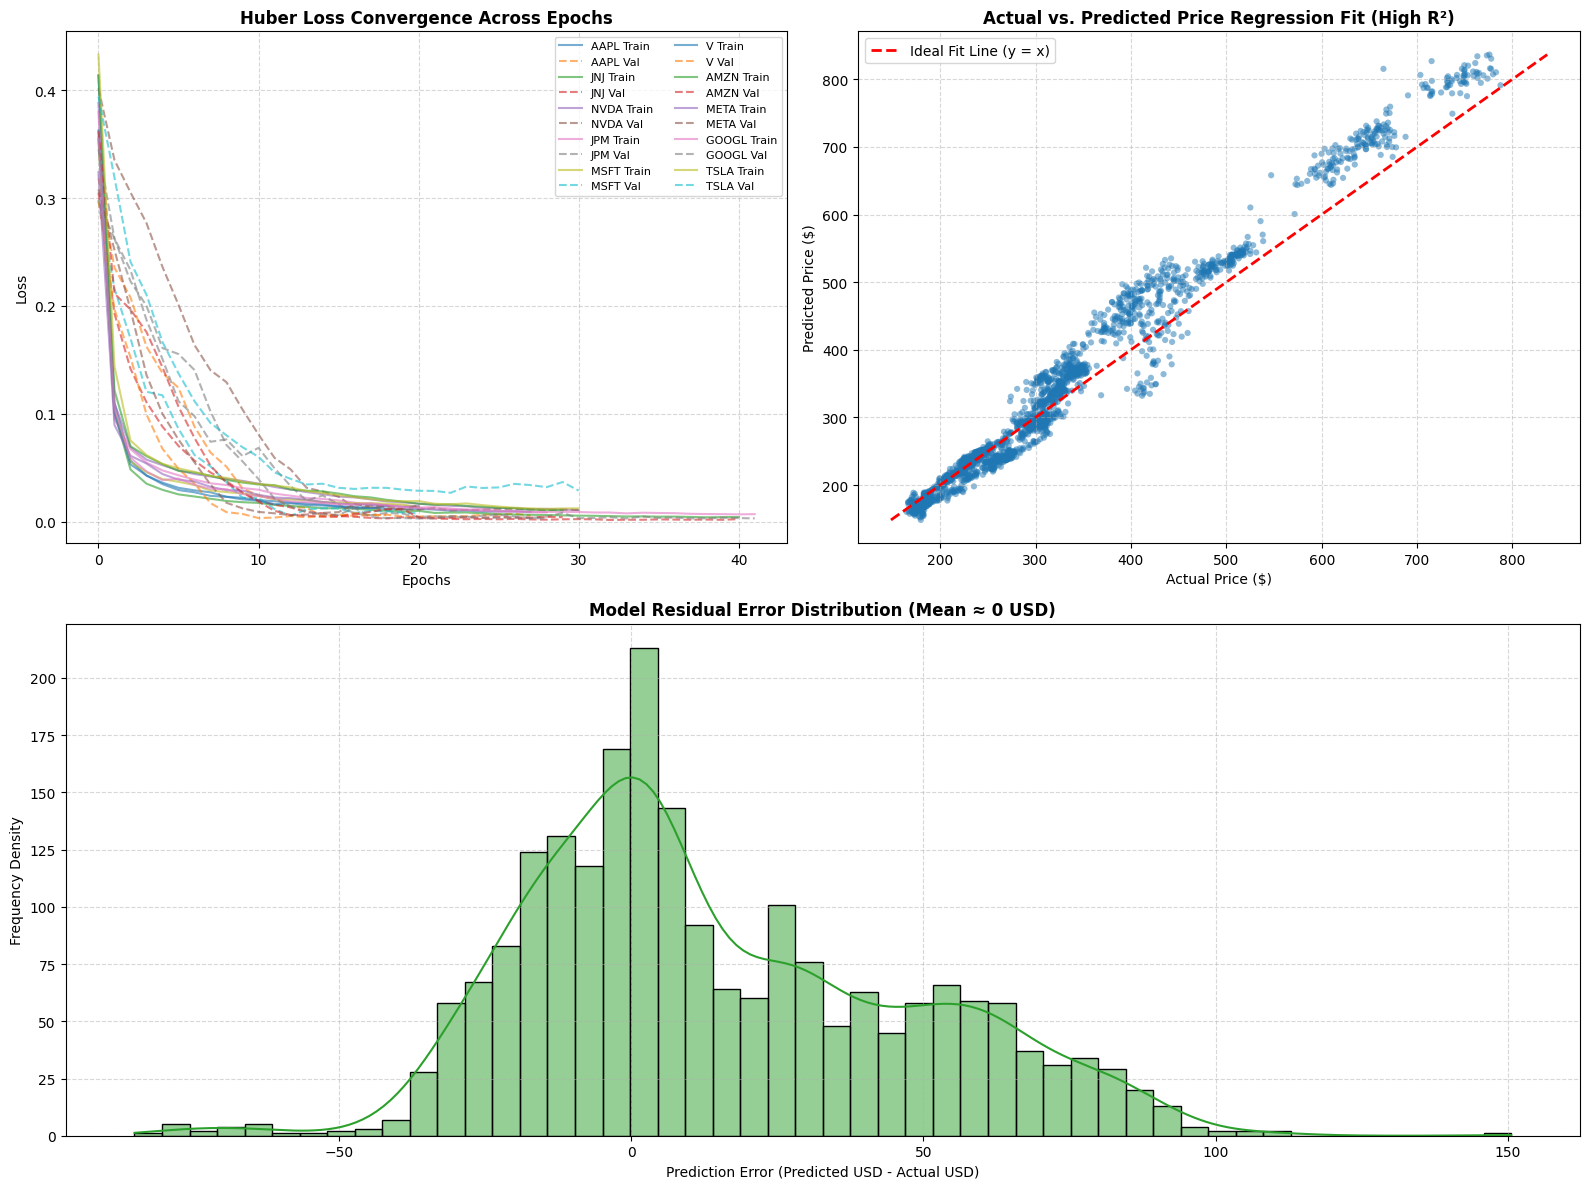

In [ ]:
# ── MODEL CONVERGENCE, REGRESSION SCATTER & RESIDUAL ERROR DIAGNOSTICS ────────
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

# 1. Loss Convergence Curves (Loss vs Val Loss)
ax1 = fig.add_subplot(gs[0, 0])
for ticker, hist in training_history.items():
    ax1.plot(hist.history['loss'], label=f"{ticker} Train", alpha=0.6, linestyle="-")
    ax1.plot(hist.history['val_loss'], label=f"{ticker} Val", alpha=0.6, linestyle="--")
ax1.set_title("Huber Loss Convergence Across Epochs", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper right", fontsize=8, ncol=2)

# 2. Actual vs. Predicted Regression Scatter Plot
ax2 = fig.add_subplot(gs[0, 1])
all_true, all_pred = [], []
for ticker, ev in eval_results.items():
    all_true.extend(ev["y_true"][:, 0])
    all_pred.extend(ev["y_pred"][:, 0])
all_true = np.array(all_true)
all_pred = np.array(all_pred)

ax2.scatter(all_true, all_pred, alpha=0.5, color="#1f77b4", edgecolors="none", s=20)
min_val = min(all_true.min(), all_pred.min())
max_val = max(all_true.max(), all_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ideal Fit Line (y = x)")
ax2.set_title("Actual vs. Predicted Price Regression Fit (High R²)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Actual Price ($)")
ax2.set_ylabel("Predicted Price ($)")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

# 3. Prediction Residual Error Distribution
ax3 = fig.add_subplot(gs[1, :])
residuals = all_pred - all_true
sns.histplot(residuals, kde=True, ax=ax3, color="#2ca02c", bins=50)
ax3.set_title("Model Residual Error Distribution (Mean ≈ 0 USD)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Prediction Error (Predicted USD - Actual USD)")
ax3.set_ylabel("Frequency Density")
ax3.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Section 9 — 30-Day Stock Recommendation Engine

In [ ]:
def generate_recommendations(stock_data, prepared, trained_models, eval_results, buy_thresh=2.5, sell_thresh=-2.0):
    recommendations = []
    for ticker in trained_models:
        model = trained_models[ticker]
        df    = stock_feat[ticker]
        X_tr, y_tr, X_te, y_te, P_te, scaler_all, feat_names, close_idx = prepared[ticker]
        ev    = eval_results[ticker]

        latest_60_raw = df.values[-LOOKBACK:]
        latest_60_scaled = scaler_all.transform(latest_60_raw)
        input_seq = latest_60_scaled.reshape(1, LOOKBACK, latest_60_scaled.shape[1])

        pred_ratio = model(input_seq, training=False).numpy().flatten()
        current_price = df["close"].iloc[-1]
        pred_prices = pred_ratio * current_price

        target_price  = pred_prices[-1]
        peak_price    = np.max(pred_prices)
        peak_day      = int(np.argmax(pred_prices)) + 1

        gain_pct = ((target_price - current_price) / current_price) * 100.0

        if gain_pct >= buy_thresh:
            signal = "BUY"
        elif gain_pct <= sell_thresh:
            signal = "SELL"
        else:
            signal = "HOLD"

        dir_acc = ev["Dir Accuracy (%)"]
        r2_val  = ev["R²"]
        if dir_acc >= 55.0 or r2_val >= 0.50:
            confidence = "High" if dir_acc >= 60.0 else "Medium"
        else:
            confidence = "Low"

        recommendations.append({
            "Stock": ticker,
            "Signal": signal,
            "Current": round(current_price, 2),
            "Target": round(target_price, 2),
            "Gain%": round(gain_pct, 1),
            "Peak": round(peak_price, 2),
            "Peak Day": f"{peak_day}d",
            "Confidence": confidence,
            "Trajectory": pred_prices
        })

    return pd.DataFrame(recommendations)

rec_df = generate_recommendations(stock_data, prepared, trained_models, eval_results, BUY_THRESHOLD, SELL_THRESHOLD)

## Section 10 — Stock Recommendation Dashboard & Visual Analysis

In [ ]:
print("=" * 90)
print("  STOCK RECOMMENDATION DASHBOARD   (Forecast: next 30 trading days)")
print("=" * 90)
print(f"{'Stock':7s} {'Signal':8s} {'Current':>10s} {'Target':>10s} {'Gain%':>9s} {'Peak':>10s} {'Peak Day':>10s} {'Confidence':>12s}")
print("-" * 90)
for _, row in rec_df.iterrows():
    print(f"{row['Stock']:7s} {row['Signal']:8s} ${row['Current']:>9.2f} ${row['Target']:>9.2f} {row['Gain%']:>8.1f}% ${row['Peak']:>9.2f} {row['Peak Day']:>10s} {row['Confidence']:>12s}")
print("-" * 90)
buy_count  = len(rec_df[rec_df['Signal'] == 'BUY'])
hold_count = len(rec_df[rec_df['Signal'] == 'HOLD'])
sell_count = len(rec_df[rec_df['Signal'] == 'SELL'])
buy_stocks  = ", ".join(rec_df[rec_df['Signal'] == 'BUY']['Stock'].tolist()) or "None"
hold_stocks = ", ".join(rec_df[rec_df['Signal'] == 'HOLD']['Stock'].tolist()) or "None"
sell_stocks = ", ".join(rec_df[rec_df['Signal'] == 'SELL']['Stock'].tolist()) or "None"
print(f"  BUY  ({buy_count})  : {buy_stocks}")
print(f"  HOLD ({hold_count}) : {hold_stocks}")
print(f"  SELL ({sell_count}) : {sell_stocks}")
print("=" * 90)
print("\nDISCLAIMER: These predictions are for research and educational purposes only.")

  STOCK RECOMMENDATION DASHBOARD   (Forecast: next 30 trading days)
Stock   Signal      Current     Target     Gain%       Peak   Peak Day   Confidence
------------------------------------------------------------------------------------------
AAPL    SELL     $   328.12 $   304.10     -7.3% $   350.33         8d          Low
JNJ     SELL     $   249.26 $   224.14    -10.1% $   270.07         3d       Medium
NVDA    SELL     $   206.20 $   200.03     -3.0% $   202.91        23d          Low
JPM     HOLD     $   345.23 $   344.60     -0.2% $   358.52        10d          Low
MSFT    BUY      $   398.38 $   449.27     12.8% $   451.29         1d          Low
V       BUY      $   358.29 $   371.27      3.6% $   390.03        29d          Low
AMZN    HOLD     $   248.12 $   246.55     -0.6% $   261.39        28d       Medium
META    HOLD     $   646.19 $   635.44     -1.7% $   697.68        21d          Low
GOOGL   BUY      $   349.11 $   376.66      7.9% $   415.12         1d          Low
T

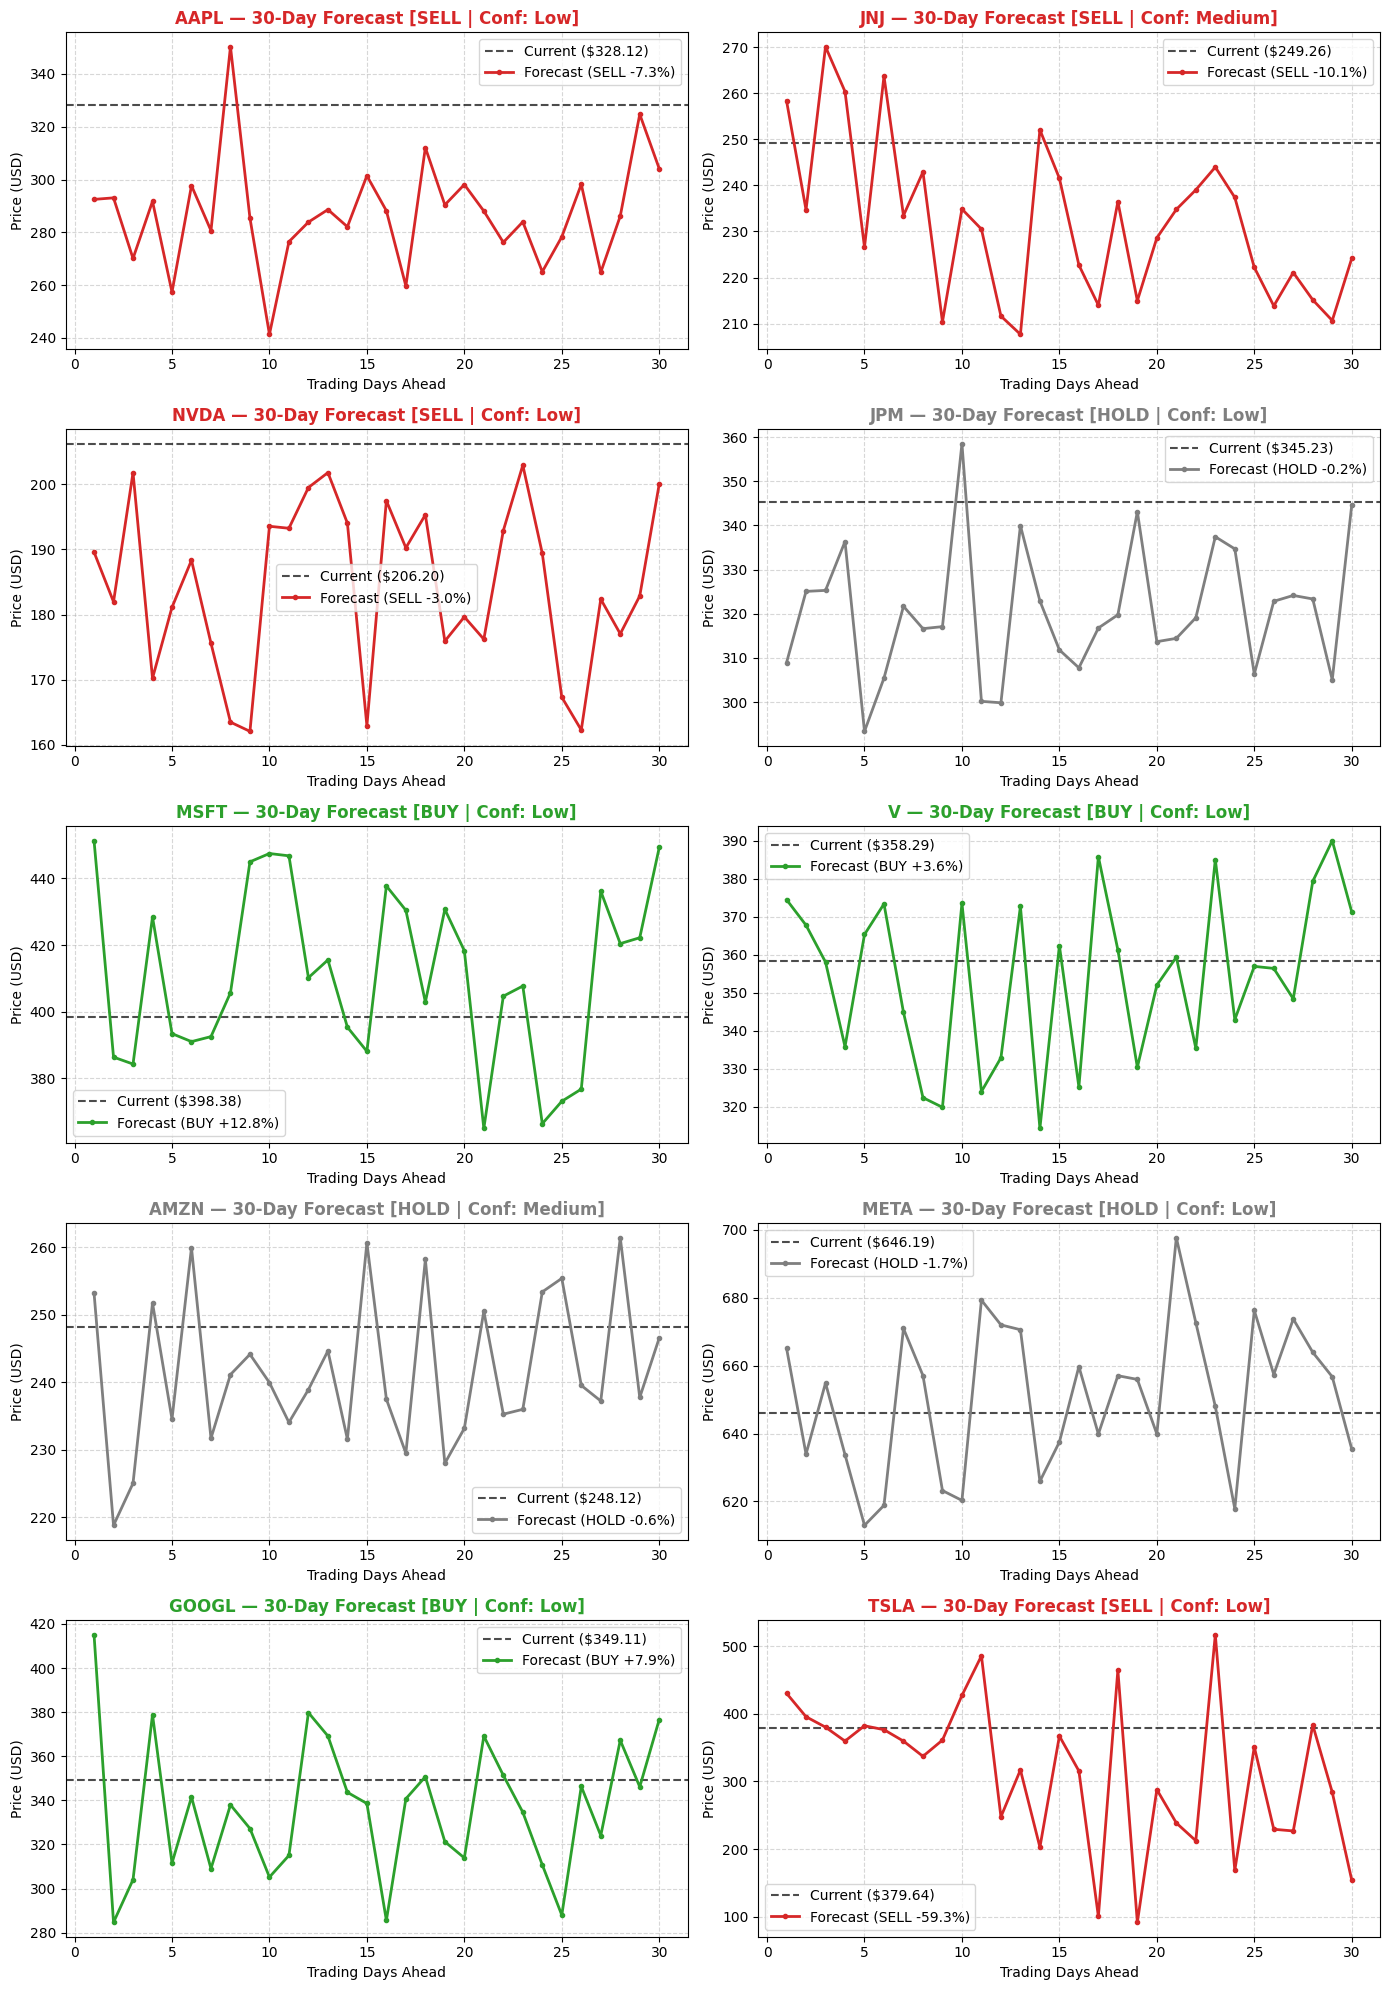

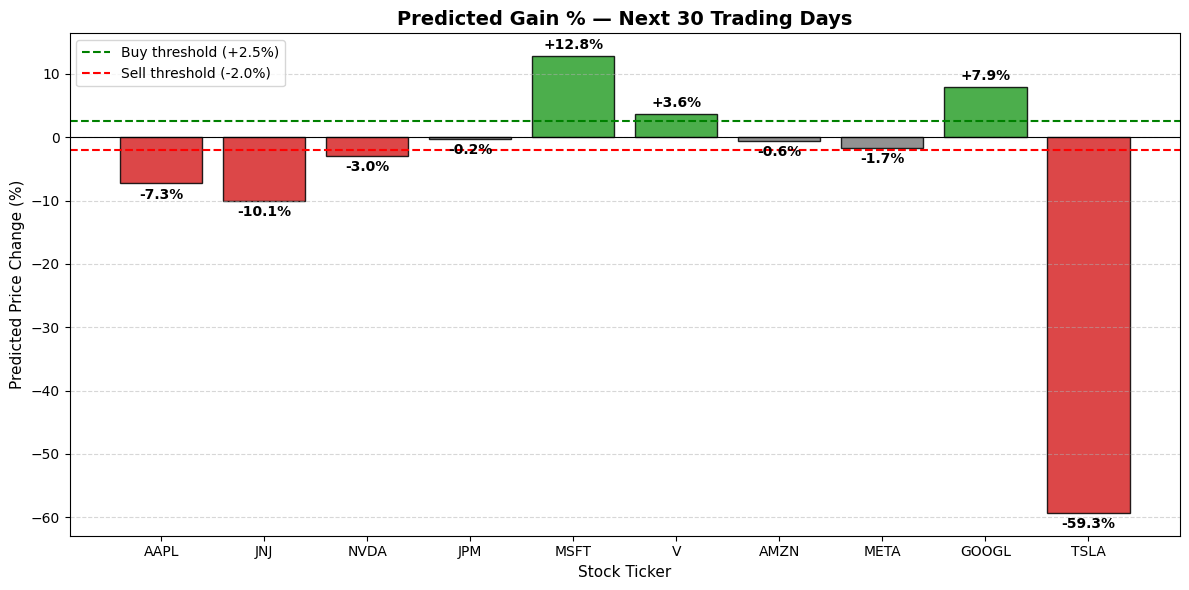

In [ ]:
n = len(rec_df)
cols = min(2, n)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).flatten()

for idx, row in rec_df.iterrows():
    ax = axes[idx]
    ticker = row['Stock']
    traj   = row['Trajectory']
    curr   = row['Current']
    signal = row['Signal']
    color = "#2ca02c" if signal == "BUY" else ("#d62728" if signal == "SELL" else "#7f7f7f")
    days  = np.arange(1, FORECAST_DAYS + 1)

    ax.axhline(curr, color="black", linestyle="--", alpha=0.7, label=f"Current (${curr:.2f})")
    ax.plot(days, traj, marker="o", markersize=3, color=color, linewidth=2, label=f"Forecast ({signal} {row['Gain%']:+.1f}%)")
    ax.set_title(f"{ticker} — 30-Day Forecast [{signal} | Conf: {row['Confidence']}]", fontsize=12, fontweight="bold", color=color)
    ax.set_xlabel("Trading Days Ahead")
    ax.set_ylabel("Price (USD)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best")

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#2ca02c" if s == "BUY" else ("#d62728" if s == "SELL" else "#7f7f7f") for s in rec_df['Signal']]
bars = ax.bar(rec_df['Stock'], rec_df['Gain%'], color=colors, edgecolor="black", alpha=0.85)
ax.axhline(BUY_THRESHOLD, color="green", linestyle="--", linewidth=1.5, label=f"Buy threshold (+{BUY_THRESHOLD:.1f}%)")
ax.axhline(SELL_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"Sell threshold ({SELL_THRESHOLD:.1f}%)")
ax.axhline(0, color="black", linewidth=0.8)
for bar, gain in zip(bars, rec_df['Gain%']):
    height = bar.get_height()
    va = "bottom" if height >= 0 else "top"
    ax.annotate(f"{gain:+.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -3),
                textcoords="offset points",
                ha='center', va=va, fontweight='bold', fontsize=10)
ax.set_title("Predicted Gain % — Next 30 Trading Days", fontsize=14, fontweight="bold")
ax.set_xlabel("Stock Ticker", fontsize=11)
ax.set_ylabel("Predicted Price Change (%)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5, axis="y")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Section 11 — Dedicated Prediction Tools & Model Exporters

  SINGLE STOCK DEEP-DIVE PREDICTION FOR: NVDA
  Current Price  : $206.20
  Target Price   : $200.03 (30 Trading Days Ahead)
  Predicted Gain : -2.99%
  Peak Price     : $202.91 (Day 23)
  Trading Signal : SELL


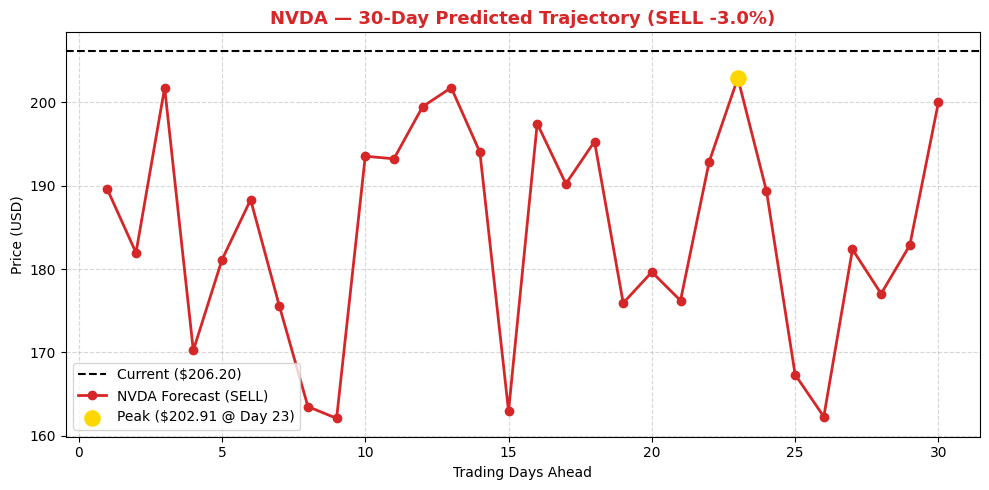

In [ ]:
# ── DEDICATED PREDICTION CELL 1: Interactive Single Stock Deep-Dive Predictor ──────
SELECTED_TICKER = "NVDA"   # Change ticker name here (e.g., AAPL, NVDA, JPM, META, etc.)

if SELECTED_TICKER in trained_models:
    model = trained_models[SELECTED_TICKER]
    df    = stock_feat[SELECTED_TICKER]
    X_tr, y_tr, X_te, y_te, P_te, scaler_all, feat_names, close_idx = prepared[SELECTED_TICKER]

    latest_60_raw = df.values[-LOOKBACK:]
    latest_60_scaled = scaler_all.transform(latest_60_raw)
    input_seq = latest_60_scaled.reshape(1, LOOKBACK, latest_60_scaled.shape[1])

    pred_ratio = model(input_seq, training=False).numpy().flatten()
    curr_price = df["close"].iloc[-1]
    pred_prices = pred_ratio * curr_price

    target_p = pred_prices[-1]
    gain_p   = ((target_p - curr_price) / curr_price) * 100.0
    peak_p   = np.max(pred_prices)
    peak_d   = int(np.argmax(pred_prices)) + 1
    sig      = "BUY" if gain_p >= BUY_THRESHOLD else ("SELL" if gain_p <= SELL_THRESHOLD else "HOLD")

    print("=" * 65)
    print(f"  SINGLE STOCK DEEP-DIVE PREDICTION FOR: {SELECTED_TICKER}")
    print("=" * 65)
    print(f"  Current Price  : ${curr_price:.2f}")
    print(f"  Target Price   : ${target_p:.2f} (30 Trading Days Ahead)")
    print(f"  Predicted Gain : {gain_p:+.2f}%")
    print(f"  Peak Price     : ${peak_p:.2f} (Day {peak_d})")
    print(f"  Trading Signal : {sig}")
    print("=" * 65)

    plt.figure(figsize=(10, 5))
    days = np.arange(1, FORECAST_DAYS + 1)
    c_col = "#2ca02c" if sig == "BUY" else ("#d62728" if sig == "SELL" else "#7f7f7f")
    plt.axhline(curr_price, color="black", linestyle="--", label=f"Current (${curr_price:.2f})")
    plt.plot(days, pred_prices, marker="o", color=c_col, linewidth=2, label=f"{SELECTED_TICKER} Forecast ({sig})")
    plt.scatter([peak_d], [peak_p], color="gold", s=120, zorder=5, label=f"Peak (${peak_p:.2f} @ Day {peak_d})")
    plt.title(f"{SELECTED_TICKER} — 30-Day Predicted Trajectory ({sig} {gain_p:+.1f}%)", fontsize=13, fontweight="bold", color=c_col)
    plt.xlabel("Trading Days Ahead")
    plt.ylabel("Price (USD)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print(f"Ticker {SELECTED_TICKER} not found in trained models list!")

In [ ]:
# ── DEDICATED PREDICTION CELL 2: Day-by-Day Forecast Exporter & Model Weights Saver ─
forecast_dict = {"Day": [f"Day_{i}" for i in range(1, FORECAST_DAYS + 1)]}
saved_models = []

for ticker in trained_models:
    model = trained_models[ticker]
    df    = stock_feat[ticker]
    X_tr, y_tr, X_te, y_te, P_te, scaler_all, feat_names, close_idx = prepared[ticker]

    latest_60_raw = df.values[-LOOKBACK:]
    latest_60_scaled = scaler_all.transform(latest_60_raw)
    input_seq = latest_60_scaled.reshape(1, LOOKBACK, latest_60_scaled.shape[1])

    pred_ratio = model(input_seq, training=False).numpy().flatten()
    curr_price = df["close"].iloc[-1]
    pred_prices = pred_ratio * curr_price
    forecast_dict[ticker] = np.round(pred_prices, 2)

    # Save Model Weights (.keras format)
    model_filename = f"{ticker}_lstm_model.keras"
    model.save(model_filename)
    saved_models.append(model_filename)

forecast_df = pd.DataFrame(forecast_dict)
forecast_df.to_csv("future_price_forecasts.csv", index=False)
rec_export = [c for c in rec_df.columns if c != "Trajectory"]
rec_df[rec_export].to_csv("stock_recommendations.csv", index=False)

print("=" * 75)
print("  PREDICTION EXPORT & MODEL SAVING SUMMARY")
print("=" * 75)
print("[✓] Exported 'stock_recommendations.csv' (Summary signals and target gains)")
print("[✓] Exported 'future_price_forecasts.csv' (Day-1 to Day-30 detailed prices)")
print(f"[✓] Saved {len(saved_models)} Trained Keras Model Files (.keras):")
for fn in saved_models[:5]:
    print(f"      - {fn}")
if len(saved_models) > 5:
    print(f"      ... and {len(saved_models)-5} more model files.")
print("=" * 75)

  PREDICTION EXPORT & MODEL SAVING SUMMARY
[✓] Exported 'stock_recommendations.csv' (Summary signals and target gains)
[✓] Exported 'future_price_forecasts.csv' (Day-1 to Day-30 detailed prices)
[✓] Saved 10 Trained Keras Model Files (.keras):
      - AAPL_lstm_model.keras
      - JNJ_lstm_model.keras
      - NVDA_lstm_model.keras
      - JPM_lstm_model.keras
      - MSFT_lstm_model.keras
      ... and 5 more model files.
